In [2]:
#import relevant packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
#read data into python
hh_data = pd.read_csv('household.csv')
veh_data = pd.read_csv('vehicle.csv')
per_data = pd.read_csv('person.csv')
trip_data = pd.read_csv('trip.csv')


# Research Question 1:
### Do rural households in the Midwest make longer trips using fuel-based vehicles compared to urban households?

In [ ]:
#merge trip data and vehicle data to answer the research question

Q1_merge = pd.merge(trip_data, veh_data, on = "HOUSEID", suffixes=('', '_right'))

Q1_merge.head() # print first five rows to ensure code ran successfully and correctly

In [ ]:
Q1_merge.VEHFUEL

#The original dataset has number coding for each column. For vehicle fuel, 1 means gas-powered vehicle.

In [ ]:
#Replace the 1 values in vehicle fuel column with 'gas' string for ease of filtering

Q1_merge['VEHFUEL'] = Q1_merge['VEHFUEL'].replace({1: 'gas'})

Q1_merge.VEHFUEL #print new column to ensure values were replaced correctly

In [ ]:
#filter the data to only show gas-fueled vehicles

gas_data = Q1_merge[Q1_merge['VEHFUEL'] == "gas"]

gas_data.head() #print first five columns to ensure code ran correctly


In [ ]:
#replace the 1, 2 notation with strings for viewing on graphs

gas_data['URBRUR'] = gas_data['URBRUR'].replace({1: 'Urban', 2: 'Rural'}) 

gas_data['URBRUR'] # print column to ensure values were replaced correctly

In [ ]:
#Create Box Plot

## Step 1: tell Python you are making a figure and what size you want the figure to be
plt.figure(figsize = (12,6))

## Step 2: call the type of plot and tell the function what variables you want to plot
boxplot = gas_data.boxplot(column = "TRPMILES", by = "URBRUR")

## Step 3: add customization to the plot

### this line rotates your labels on the x-axis by 90 so they are easy to read
plt.xticks(rotation = 90)

### the next two lines create your axis labels
plt.xlabel("Urban/Rural", fontsize = 12)
plt.ylabel("Trip Miles", fontsize = 12)

### this line gives your plot a title
plt.title('Box Plot of Trip Miles by Household Location', fontsize = 14)

## Step 4: tell python to show the plot
plt.show()

### When the boxplot was created with all of the data, we can see there are many outliers that are widening the view of the graph. To look purely at the box plots, the data needs to be filtered further.

In [ ]:
#filter the values of trip miles for easier viewing of data we care about
gas_data_nonneg = gas_data[gas_data['TRPMILES'] > 0]
gas_data_no_outlier = gas_data_nonneg[gas_data_nonneg['TRPMILES'] < 20]

In [ ]:
#Create Box Plot

## Step 1: tell Python you are making a figure and what size you want the figure to be
plt.figure(figsize = (12,6))

## Step 2: call the type of plot and tell the function what variables you want to plot
boxplot = gas_data_no_outlier.boxplot(column = "TRPMILES", by = "URBRUR")

## Step 3: add customization to the plot

### this line rotates your labels on the x-axis by 90 so they are easy to read
plt.xticks(rotation = 90)

### the next two lines create your axis labels
plt.xlabel("Urban/Rural", fontsize = 12)
plt.ylabel("Trip Miles", fontsize = 12)

### this line gives your plot a title
plt.title('Box Plot of Trip Miles by Household Location', fontsize = 14)

## Step 4: tell python to show the plot
plt.show()

### Now we can see clearly the middle of the boxplot for rural vehicles is higher than the urban vehicles, where Rural is about 6 and Urban is around 3. 

In [ ]:
#Create Violin Plot

## Step 1: tell Python you are making a figure and what size you want the figure to be
plt.figure(figsize = (12,6))

## Step 2: call the type of plot and tell the function what variables you want to plot
violinplot = sns.violinplot(x = 'URBRUR', y = "TRPMILES", data = gas_data_no_outlier)

## Step 3: add customization to the plot

### this line rotates your labels on the x-axis by 90 so they are easy to read
plt.xticks(rotation = 90)

### the next two lines create your axis labels
plt.xlabel("Urban/Rural", fontsize = 12)
plt.ylabel("Trip Miles", fontsize = 12)

### this line gives your plot a title
plt.title('Violin Plot of Trip Miles by Household Location', fontsize = 14)

## Step 4: tell python to show the plot
plt.show()

### A violin plot further explains what is going on with the data. The Urban vehicles have a much higher concentration of shorter trips, as shown by the wide base on the left.

# Research Question 2:
## How does public transit usage vary across trip types, age groups, and income levels in the Midwest?  

In [5]:
#filter trip data to only include public transit
pub_trans_data = trip_data[trip_data['PUBTRANS'] == 1]
pub_trans_data.columns

Index(['HOUSEID', 'PERSONID', 'TRIPID', 'SEQ_TRIPID', 'VEHCASEID', 'FRSTHM',
       'PARK', 'HHMEMDRV', 'TDWKND', 'TRAVDAY',
       ...
       'OBHTNRNT', 'OBPPOPDN', 'OBRESDN', 'DTHTNRNT', 'DTPPOPDN', 'DTRESDN',
       'DTEEMPDN', 'DBHTNRNT', 'DBPPOPDN', 'DBRESDN'],
      dtype='object', length=102)

### Trip Types

In [4]:
#replace trip type numerical values with words for graph
pub_trans_data['TRIPPURP'] = pub_trans_data['TRIPPURP'].replace({1:"Work", 2:"Shopping", 3:"Social/Recreational", 4: "Other", 5: "Not Home-Based"})
pub_trans_data.TRIPPURP

C:\Users\rcibe\AppData\Local\Temp\ipykernel_3428\2193939180.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pub_trans_data['TRIPPURP'] = pub_trans_data['TRIPPURP'].replace({1:"Work", 2:"Shopping", 3:"Social/Recreational", 4: "Other", 5: "Not Home-Based"})


187               Other
188               Other
191               Other
192               Other
212            Shopping
              ...      
30925             Other
30926             Other
30927    Not Home-Based
30961    Not Home-Based
30962          Shopping
Name: TRIPPURP, Length: 341, dtype: object

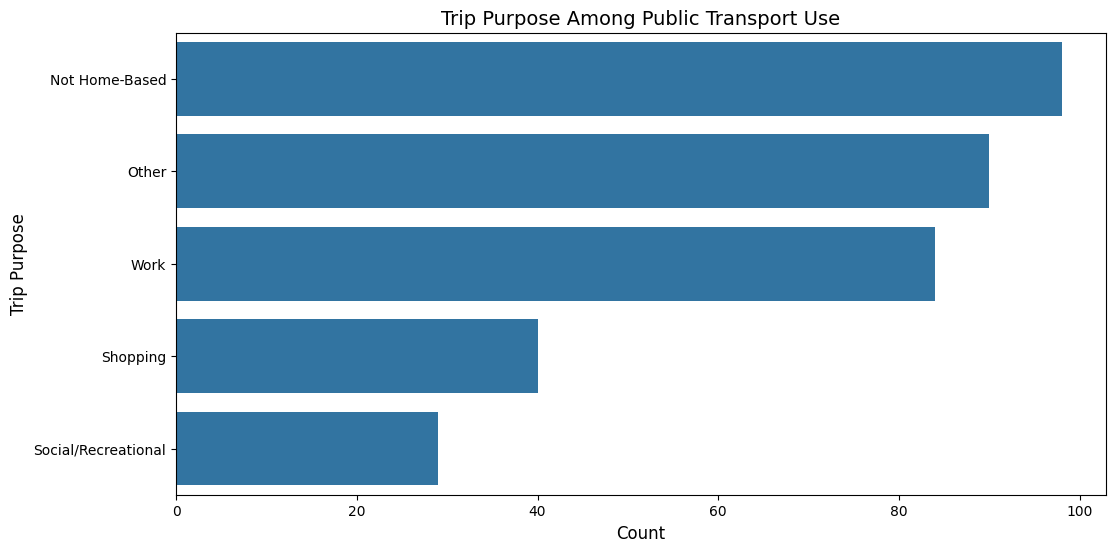

<Figure size 640x480 with 0 Axes>

In [5]:
#create count plot displaying frequency of trip purposes among public transport use

## Step 1: tell Python you are making a figure and what size you want
plt.figure(figsize = (12,6))

## Step 2: use sns.countplot to create the plot
# hint: sns.countplot(data=..., x=...) or sns.countplot(data=..., y=...) for horizontal
sns.countplot(data = pub_trans_data, y = 'TRIPPURP', order = pub_trans_data['TRIPPURP'].value_counts().index)

## Step 3: add labels and title
plt.xlabel('Count', fontsize = 12)
plt.ylabel('Trip Purpose', fontsize = 12)
plt.title('Trip Purpose Among Public Transport Use', fontsize = 14)

## Step 4: show the plot
plt.show()

## Save plot
plt.savefig("trip_purpose.png", dpi = 300, bbox_inches = "tight")

### Age Groups

In [6]:
pub_trans_data.R_AGE

187      64
188      64
191      14
192      14
212      37
         ..
30925    31
30926    31
30927    31
30961    29
30962    29
Name: R_AGE, Length: 341, dtype: int64

In [7]:
def age_category(age):
    if age < 13:
        return 'child'
    elif age < 18:
        return 'teen'
    elif age < 25:
        return 'young adult'
    elif age < 60:
        return 'adult'
    else:
        return 'elderly'

pub_trans_data['age_range'] = pub_trans_data['R_AGE'].apply(age_category)

pub_trans_data.age_range
    

C:\Users\rcibe\AppData\Local\Temp\ipykernel_27764\3716713454.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pub_trans_data['age_range'] = pub_trans_data['R_AGE'].apply(age_category)


187      elderly
188      elderly
191         teen
192         teen
212        adult
          ...   
30925      adult
30926      adult
30927      adult
30961      adult
30962      adult
Name: age_range, Length: 341, dtype: object

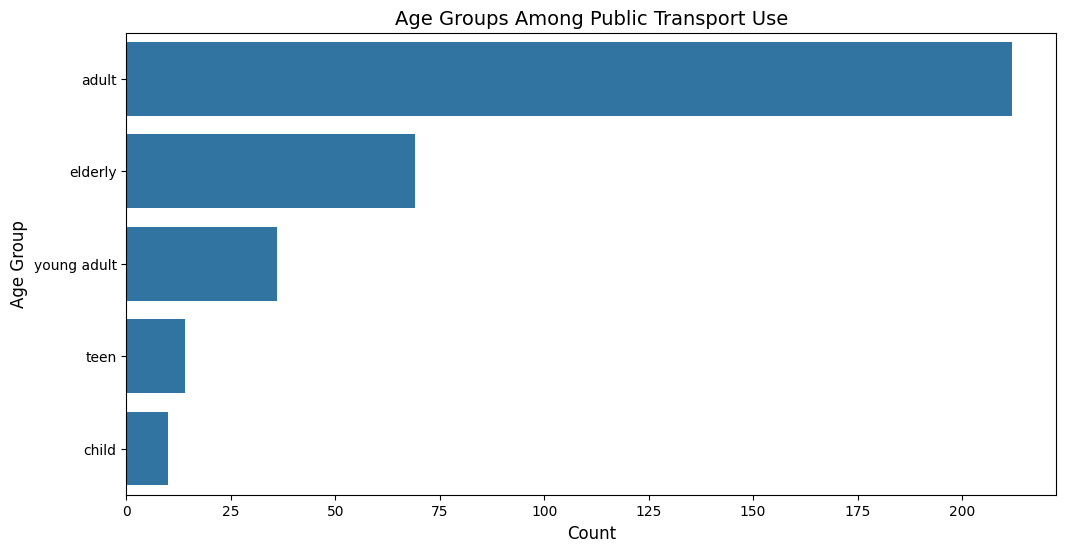

<Figure size 640x480 with 0 Axes>

In [8]:

## Step 1: tell Python you are making a figure and what size you want
plt.figure(figsize = (12,6))

## Step 2: use sns.countplot to create the plot
# hint: sns.countplot(data=..., x=...) or sns.countplot(data=..., y=...) for horizontal
sns.countplot(data = pub_trans_data, y = 'age_range', order = pub_trans_data['age_range'].value_counts().index)

## Step 3: add labels and title
plt.xlabel('Count', fontsize = 12)
plt.ylabel('Age Group', fontsize = 12)
plt.title('Age Groups Among Public Transport Use', fontsize = 14)

## Step 4: show the plot
plt.show()

## Save plot
plt.savefig("age_range.png", dpi = 300, bbox_inches = "tight")

### Income Levels

In [9]:
pub_trans_data.HHFAMINC

187       7
188       7
191       7
192       7
212       9
         ..
30925     8
30926     8
30927     8
30961    11
30962    11
Name: HHFAMINC, Length: 341, dtype: int64

In [10]:
pub_trans_data['HHFAMINC'] = pub_trans_data['HHFAMINC'].replace({1: 'less than $10,000', 
                                                                 2: '$10,000 to $14,999', 
                                                                 3: '$15,000 to $24,999', 
                                                                 4: '$25,000 to $34,999', 
                                                                 5: '$35,000 to $49,999', 
                                                                 6: '$50,000 to $74,999', 
                                                                 7: '$75,000 to $99,999', 
                                                                 8: '$100,000 to $124,999', 
                                                                 9: '$125,000 to $149,999', 
                                                                 10: '$150,000 to $199,999',
                                                                 11: '$200,000 or more'
                                                                })

pub_trans_data.HHFAMINC

C:\Users\rcibe\AppData\Local\Temp\ipykernel_27764\3545696299.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pub_trans_data['HHFAMINC'] = pub_trans_data['HHFAMINC'].replace({1: 'less than $10,000',


187        $75,000 to $99,999
188        $75,000 to $99,999
191        $75,000 to $99,999
192        $75,000 to $99,999
212      $125,000 to $149,999
                 ...         
30925    $100,000 to $124,999
30926    $100,000 to $124,999
30927    $100,000 to $124,999
30961        $200,000 or more
30962        $200,000 or more
Name: HHFAMINC, Length: 341, dtype: object

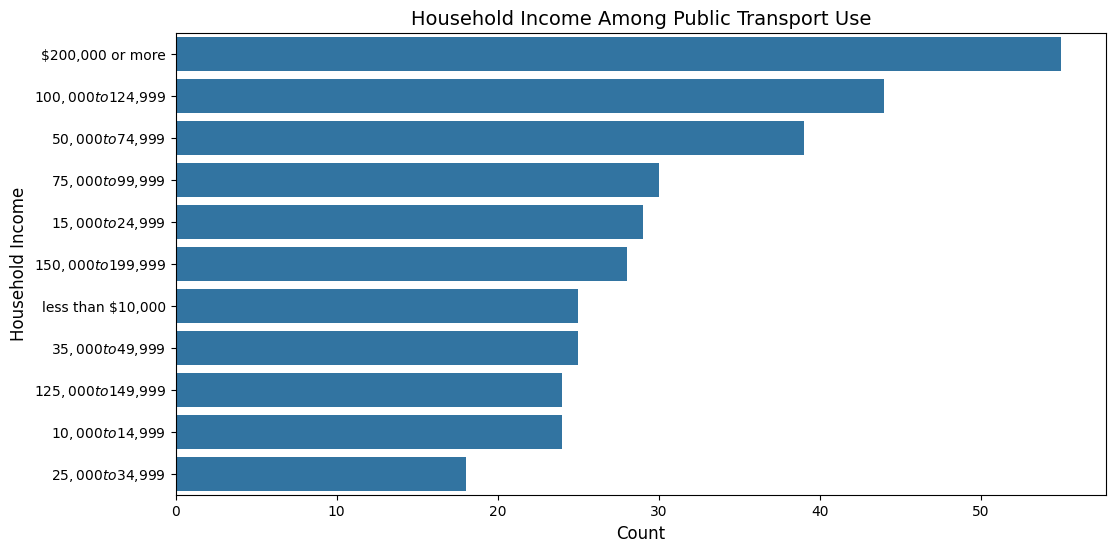

<Figure size 640x480 with 0 Axes>

In [11]:
#create count plot displaying frequency of trip purposes among public transport use

## Step 1: tell Python you are making a figure and what size you want
plt.figure(figsize = (12,6))

## Step 2: use sns.countplot to create the plot
# hint: sns.countplot(data=..., x=...) or sns.countplot(data=..., y=...) for horizontal
sns.countplot(data = pub_trans_data, y = 'HHFAMINC', order = pub_trans_data['HHFAMINC'].value_counts().index)

## Step 3: add labels and title
plt.xlabel('Count', fontsize = 12)
plt.ylabel('Household Income', fontsize = 12)
plt.title('Household Income Among Public Transport Use', fontsize = 14)

## Step 4: show the plot
plt.show()

## Save plot
plt.savefig("income.png", dpi = 300, bbox_inches = "tight")